# BirdCLEF+ 2025 — Dylan Liu 4th-place style Kaggle reimplementation

This notebook is inspired by the public 4th-place BirdCLEF+ 2025 solution by Dylan Liu.

The goal is to replicate the original repository structure:

- `SETTINGS.json`-style path configuration
- `prepare_data.py`-style spectrogram cache
- `train.py`-style supervised / semi-supervised stages
- `predict.py`-style segmented soundscape inference
- SED EfficientNet model with attention pooling
- Soft AUC / AUC ranking losses
- optional pseudo-label generation
- optional multi-backbone registry

Recommended first run on Kaggle:

1. Keep `RUN_MODE = "quick_debug"` and run all cells.
2. After it works, switch to `RUN_MODE = "report_train"`.
3. For a closer full run, switch to `RUN_MODE = "dylan_like_long"` and train selected configs one by one.

## 0. Practical notes

This version has:

- precomputed `.npy` mel spectrogram cache;
- class-balanced dataset resampling;
- original-like SED attention head;
- original-like `AUCLoss` and `SoftAUCLoss`;
- SWA checkpoint option;
- pseudo-label generation skeleton that actually writes `semi_train_preds.csv`;
- multi-model config registry.

For stable Kaggle notebook execution, `num_workers` is set to `0` by default to avoid noisy multiprocessing cleanup errors in Jupyter.

In [1]:
# ============================================================
# 1. SETTINGS-style configuration
# ============================================================
from dataclasses import dataclass, asdict
from pathlib import Path
import os, sys, json, math, random, time, warnings, gc, ast, shutil
warnings.filterwarnings("ignore")

@dataclass
class Settings:
    # Your actual Kaggle competition dataset path.
    competition_root: str = "/kaggle/input/competitions/birdclef-2025"

    # Dylan-like generated directories.
    work_dir: str = "/kaggle/working/birdclef_dylan_like"
    data_cache_dir: str = "/kaggle/working/birdclef_dylan_like/data_cache"
    model_dir: str = "/kaggle/working/birdclef_dylan_like/models"
    output_dir: str = "/kaggle/working/birdclef_dylan_like/output"

    # Raw dataset subpaths. These are resolved in Cell 3.
    train_datadir: str = ""
    train_csv: str = ""
    taxonomy_csv: str = ""
    train_soundscapes: str = ""
    test_soundscapes: str = ""
    submission_csv: str = ""

settings = Settings()

# Run modes:
# - quick_debug: small cache + short training; used to verify the pipeline.
# - report_train: stronger but still practical on Kaggle.
# - dylan_like_long: closer to original training schedule; expensive.
RUN_MODE = "report_train"  # quick_debug | report_train | dylan_like_long | cache_only | inference_only

# Select the model/data config to train first.
# Start with tf_efficientnet_lite0_v1_first10. Later try efficientnet_b2_v1_first10 or tf_efficientnetv2_b3_v1_first10.
SELECTED_CONFIGS = ["tf_efficientnet_lite0_v1_first10"]

# Optional switches.
RUN_PREPARE_DATA = True
RUN_TRAINING = True
RUN_PSEUDO_LABEL_GENERATION = False
RUN_TEST_INFERENCE = False
RUN_SUBMISSION = False

# Kaggle/Jupyter stability: keep 0 unless you really need speed and your environment is stable.
GLOBAL_NUM_WORKERS = 0

for d in [settings.work_dir, settings.data_cache_dir, settings.model_dir, settings.output_dir]:
    Path(d).mkdir(parents=True, exist_ok=True)

print("RUN_MODE:", RUN_MODE)
print(json.dumps(asdict(settings), indent=2))

RUN_MODE: report_train
{
  "competition_root": "/kaggle/input/competitions/birdclef-2025",
  "work_dir": "/kaggle/working/birdclef_dylan_like",
  "data_cache_dir": "/kaggle/working/birdclef_dylan_like/data_cache",
  "model_dir": "/kaggle/working/birdclef_dylan_like/models",
  "output_dir": "/kaggle/working/birdclef_dylan_like/output",
  "train_datadir": "",
  "train_csv": "",
  "taxonomy_csv": "",
  "train_soundscapes": "",
  "test_soundscapes": "",
  "submission_csv": ""
}


In [2]:
# ============================================================
# 2. Install and import packages
# ============================================================
import subprocess, pkgutil

def install_if_missing(module_name, pip_name=None):
    pip_name = pip_name or module_name
    if pkgutil.find_loader(module_name) is None:
        print(f"Installing {pip_name} ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name])

# Kaggle normally has these. This only installs if missing.
install_if_missing("timm", "timm")
install_if_missing("librosa", "librosa")
install_if_missing("soundfile", "soundfile")
install_if_missing("cv2", "opencv-python")

import numpy as np
import pandas as pd
import soundfile as sf
import librosa
import cv2
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim import lr_scheduler
from torch.optim.swa_utils import AveragedModel
from torch.utils.data import Dataset, DataLoader

import timm
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
print("timm:", timm.__version__)

torch: 2.10.0+cu128
cuda available: True
timm: 1.0.26


In [3]:
# ============================================================
# 3. Resolve Kaggle dataset paths
# ============================================================
def first_existing(paths):
    for p in paths:
        p = Path(p)
        if p.exists():
            return p
    return None

root_candidates = [
    Path(settings.competition_root),
    Path("/kaggle/input/competitions/birdclef-2025"),
    Path("/kaggle/input/birdclef-2025"),
]

ROOT = first_existing(root_candidates)
assert ROOT is not None, "Could not find BirdCLEF 2025 dataset root. Check settings.competition_root."

settings.competition_root = str(ROOT)
settings.train_datadir = str(ROOT / "train_audio")
settings.train_csv = str(ROOT / "train.csv")
settings.taxonomy_csv = str(ROOT / "taxonomy.csv")
settings.train_soundscapes = str(ROOT / "train_soundscapes")
settings.test_soundscapes = str(ROOT / "test_soundscapes")
settings.submission_csv = str(ROOT / "sample_submission.csv")

print("Resolved dataset root:", ROOT)
for k, v in asdict(settings).items():
    if k.endswith("csv") or "datadir" in k or "soundscapes" in k:
        print(f"{k}: {v} | exists={Path(v).exists()}")

assert Path(settings.train_csv).exists(), "train.csv not found."
assert Path(settings.taxonomy_csv).exists(), "taxonomy.csv not found."
assert Path(settings.train_datadir).exists(), "train_audio not found."

Resolved dataset root: /kaggle/input/competitions/birdclef-2025
train_datadir: /kaggle/input/competitions/birdclef-2025/train_audio | exists=True
train_csv: /kaggle/input/competitions/birdclef-2025/train.csv | exists=True
taxonomy_csv: /kaggle/input/competitions/birdclef-2025/taxonomy.csv | exists=True
train_soundscapes: /kaggle/input/competitions/birdclef-2025/train_soundscapes | exists=True
test_soundscapes: /kaggle/input/competitions/birdclef-2025/test_soundscapes | exists=True
submission_csv: /kaggle/input/competitions/birdclef-2025/sample_submission.csv | exists=True


In [4]:
# ============================================================
# 4. Reproducibility and metadata
# ============================================================
def set_seed(seed=42):
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    # For speed. Set deterministic=True only if exact reproducibility is required.
    torch.backends.cudnn.benchmark = True

set_seed(42)

train_df_raw = pd.read_csv(settings.train_csv)
taxonomy_df = pd.read_csv(settings.taxonomy_csv)
sample_submission = pd.read_csv(settings.submission_csv) if Path(settings.submission_csv).exists() else None

species_ids = taxonomy_df["primary_label"].tolist()
label_to_idx = {label: idx for idx, label in enumerate(species_ids)}
idx_to_label = {idx: label for label, idx in label_to_idx.items()}

print("train_df:", train_df_raw.shape)
print("taxonomy_df:", taxonomy_df.shape)
print("num_classes:", len(species_ids))
display(train_df_raw.head())
display(taxonomy_df.head())

train_df: (28564, 13)
taxonomy_df: (206, 5)
num_classes: 206


,primary_label,secondary_labels,type,filename,collection,rating,url,latitude,longitude,scientific_name,common_name,author,license
0,1139490,[''],[''],1139490/CSA36385.ogg,CSA,0.0,http://colecciones.humboldt.org.co/rec/sonidos...,7.3206,-73.7128,Ragoniella pulchella,Ragoniella pulchella,Fabio A. Sarria-S,cc-by-nc-sa 4.0
1,1139490,[''],[''],1139490/CSA36389.ogg,CSA,0.0,http://colecciones.humboldt.org.co/rec/sonidos...,7.3206,-73.7128,Ragoniella pulchella,Ragoniella pulchella,Fabio A. Sarria-S,cc-by-nc-sa 4.0
2,1192948,[''],[''],1192948/CSA36358.ogg,CSA,0.0,http://colecciones.humboldt.org.co/rec/sonidos...,7.3791,-73.7313,Oxyprora surinamensis,Oxyprora surinamensis,Fabio A. Sarria-S,cc-by-nc-sa 4.0
3,1192948,[''],[''],1192948/CSA36366.ogg,CSA,0.0,http://colecciones.humboldt.org.co/rec/sonidos...,7.2800,-73.8582,Oxyprora surinamensis,Oxyprora surinamensis,Fabio A. Sarria-S,cc-by-nc-sa 4.0
4,1192948,[''],[''],1192948/CSA36373.ogg,CSA,0.0,http://colecciones.humboldt.org.co/rec/sonidos...,7.3791,-73.7313,Oxyprora surinamensis,Oxyprora surinamensis,Fabio A. Sarria-S,cc-by-nc-sa 4.0


,primary_label,inat_taxon_id,scientific_name,common_name,class_name
0,1139490,1139490,Ragoniella pulchella,Ragoniella pulchella,Insecta
1,1192948,1192948,Oxyprora surinamensis,Oxyprora surinamensis,Insecta
2,1194042,1194042,Copiphora colombiae,Copiphora colombiae,Insecta
3,126247,126247,Leptodactylus insularum,Spotted Foam-nest Frog,Amphibia
4,1346504,1346504,Neoconocephalus brachypterus,Neoconocephalus brachypterus,Insecta


In [5]:
# ============================================================
# 5. Data and model config registry
# ============================================================
@dataclass
class DataCfg:
    name: str
    fs: int = 32000
    target_duration: float = 5.0
    train_duration_range: tuple = (10.0, 10.0)
    is_first10: bool = True
    target_shape: tuple = (256, 256)  # (time_bins_for_5s, n_mels)
    n_fft: int = 2048
    hop_length: int = 64
    n_mels: int = 256
    fmin: int = 60
    fmax: int = 16000
    use_augment_cache: bool = False

@dataclass
class ModelCfg:
    version: str
    model_name: str
    data_name: str = "v1_first10"
    seed: int = 42
    fold_seed: int = 42
    device: str = "cuda"
    dtype: object = torch.float32

    n_fold: int = 6
    selected_folds: tuple = (0,)

    epochs: int = 5
    acc_start_epoch: int = 4
    batch_size: int = 16
    valid_batch_size: int = 32
    num_workers: int = 0

    pretrained: bool = False
    in_channels: int = 1
    dropout_rate: float = 0.5
    drop_rate: float = 0.2
    drop_path_rate: float = 0.5

    optimizer: str = "AdamW"
    lr: float = 5e-4
    weight_decay: float = 1e-5
    scheduler: str = "CosineAnnealingLR"
    min_lr: float = 1e-6
    pct_start: float = 0.0

    apex: bool = True
    max_grad_norm: float = 1.0

    # Closer to original: SoftAUCLoss/AUCLoss. BCE anchor helps report/debug calibration.
    criterions: tuple = ("SoftAUCLoss",)
    use_bce_anchor: bool = True
    bce_anchor_weight: float = 0.20
    auc_margin: float = 1.0

    mixup_alpha: float = 0.5
    mixup_rate: float = 1.0
    aug_prob: float = 0.5

    min_samples_per_class: int = 100
    resample_primary_only: bool = True
    min_samples_for_cv: int = 50
    cv_primary_only: bool = False

    semi_train_csv: str = ""
    semi_drop: float = 0.2

    max_cache_files: int | None = None
    max_train_rows: int | None = None
    max_valid_rows: int | None = None
    reuse_existing_checkpoint: bool = True

# Data configs inspired by the original config.py.
data_cfg_dict = {
    "v1_first10": DataCfg(name="v1_first10", target_shape=(256, 256), n_fft=2048, hop_length=64, n_mels=256, fmin=60, fmax=16000, is_first10=True),
    "v1_full":    DataCfg(name="v1_full",    target_shape=(256, 256), n_fft=2048, hop_length=64, n_mels=256, fmin=60, fmax=16000, is_first10=False),
    "v2_first10": DataCfg(name="v2_first10", target_shape=(384, 192), n_fft=1536, hop_length=64, n_mels=192, fmin=50, fmax=16000, is_first10=True),
    "v3_first10": DataCfg(name="v3_first10", target_shape=(288, 224), n_fft=2048, hop_length=128, n_mels=224, fmin=40, fmax=16000, is_first10=True),
}

# A practical subset of the original multi-backbone registry.
model_cfg_dict = {
    "tf_efficientnet_lite0_v1_first10": ModelCfg(version="tf_efficientnet_lite0_v1_first10", model_name="tf_efficientnet_lite0", data_name="v1_first10", seed=2001),
    "tf_efficientnet_lite1_v1_first10": ModelCfg(version="tf_efficientnet_lite1_v1_first10", model_name="tf_efficientnet_lite1", data_name="v1_first10", seed=11),
    "tf_efficientnet_lite2_v1_first10": ModelCfg(version="tf_efficientnet_lite2_v1_first10", model_name="tf_efficientnet_lite2", data_name="v1_first10", seed=2021),
    "efficientnet_b2_v1_first10":       ModelCfg(version="efficientnet_b2_v1_first10",       model_name="efficientnet_b2",       data_name="v1_first10", seed=121),
    "efficientnet_b3_v1_first10":       ModelCfg(version="efficientnet_b3_v1_first10",       model_name="efficientnet_b3",       data_name="v1_first10", seed=131),
    "tf_efficientnetv2_b3_v1_first10":  ModelCfg(version="tf_efficientnetv2_b3_v1_first10",  model_name="tf_efficientnetv2_b3",  data_name="v1_first10", seed=2231),
    "tf_efficientnetv2_s_v1_first10":   ModelCfg(version="tf_efficientnetv2_s_v1_first10",   model_name="tf_efficientnetv2_s",   data_name="v1_first10", seed=20211),
    "tf_efficientnetv2_b3_v2_first10":  ModelCfg(version="tf_efficientnetv2_b3_v2_first10",  model_name="tf_efficientnetv2_b3",  data_name="v2_first10", seed=72231),
    "tf_efficientnetv2_s_v3_first10":   ModelCfg(version="tf_efficientnetv2_s_v3_first10",   model_name="tf_efficientnetv2_s",   data_name="v3_first10", seed=73301),
}

def apply_run_mode(cfg: ModelCfg):
    cfg.num_workers = GLOBAL_NUM_WORKERS
    cfg.device = "cuda" if torch.cuda.is_available() else "cpu"
    cfg.apex = bool(cfg.apex and cfg.device == "cuda")

    if RUN_MODE == "quick_debug":
        cfg.epochs = 3
        cfg.acc_start_epoch = 2
        cfg.batch_size = 16
        cfg.valid_batch_size = 32
        cfg.max_cache_files = 1500
        cfg.max_train_rows = 1500
        cfg.max_valid_rows = 600
        cfg.min_samples_per_class = 40
    elif RUN_MODE == "report_train":
        cfg.epochs = 13
        cfg.acc_start_epoch = 9
        cfg.batch_size = 16
        cfg.valid_batch_size = 32
        cfg.max_cache_files = None
        cfg.max_train_rows = None
        cfg.max_valid_rows = None
        cfg.min_samples_per_class = 100
    elif RUN_MODE == "dylan_like_long":
        cfg.epochs = 22
        cfg.acc_start_epoch = 18
        cfg.batch_size = 32
        cfg.valid_batch_size = 64
        cfg.max_cache_files = None
        cfg.max_train_rows = None
        cfg.max_valid_rows = None
        cfg.min_samples_per_class = 100
    elif RUN_MODE == "cache_only":
        cfg.epochs = 0
        cfg.max_cache_files = None
    elif RUN_MODE == "inference_only":
        cfg.epochs = 0
    else:
        raise ValueError(f"Unknown RUN_MODE: {RUN_MODE}")
    return cfg

for k in model_cfg_dict:
    model_cfg_dict[k] = apply_run_mode(model_cfg_dict[k])

print("Available configs:")
for k, v in model_cfg_dict.items():
    print(k, "->", v.model_name, v.data_name, "epochs", v.epochs)

Available configs:
tf_efficientnet_lite0_v1_first10 -> tf_efficientnet_lite0 v1_first10 epochs 13
tf_efficientnet_lite1_v1_first10 -> tf_efficientnet_lite1 v1_first10 epochs 13
tf_efficientnet_lite2_v1_first10 -> tf_efficientnet_lite2 v1_first10 epochs 13
efficientnet_b2_v1_first10 -> efficientnet_b2 v1_first10 epochs 13
efficientnet_b3_v1_first10 -> efficientnet_b3 v1_first10 epochs 13
tf_efficientnetv2_b3_v1_first10 -> tf_efficientnetv2_b3 v1_first10 epochs 13
tf_efficientnetv2_s_v1_first10 -> tf_efficientnetv2_s v1_first10 epochs 13
tf_efficientnetv2_b3_v2_first10 -> tf_efficientnetv2_b3 v2_first10 epochs 13
tf_efficientnetv2_s_v3_first10 -> tf_efficientnetv2_s v3_first10 epochs 13


In [6]:
# ============================================================
# 6. Build training dataframe with multi-label targets
# ============================================================
def parse_secondary_labels(value):
    if value is None or (isinstance(value, float) and np.isnan(value)):
        return []
    if isinstance(value, list):
        return [x for x in value if x]
    try:
        parsed = ast.literal_eval(value)
        if isinstance(parsed, list):
            return [x for x in parsed if x]
    except Exception:
        pass
    return []

def make_samplename(filename):
    # Original style: class-folder + "-" + file stem.
    p = Path(filename)
    if len(p.parts) >= 2:
        return f"{p.parts[0]}-{p.stem}"
    return p.stem

def build_train_dataframe(raw_df, cfg: ModelCfg):
    df = raw_df.copy()
    df = df[df["primary_label"].isin(label_to_idx)].reset_index(drop=True)
    df["filepath"] = df["filename"].map(lambda x: str(Path(settings.train_datadir) / x))
    df["samplename"] = df["filename"].map(make_samplename)
    df["purename"] = df["filename"].map(lambda x: Path(x).stem)
    df["removed"] = 0

    label_counts = {ln: 0 for ln in species_ids}
    label_embeddings = []
    data_label_cache = []

    for _, row in df.iterrows():
        labels_here = [row["primary_label"]]
        if not cfg.cv_primary_only:
            for s in parse_secondary_labels(row.get("secondary_labels", [])):
                if s in label_to_idx:
                    labels_here.append(s)

        vec = np.zeros(len(species_ids), dtype=np.float32)
        for lab in labels_here:
            vec[label_to_idx[lab]] = 1.0
            label_counts[lab] += 1
        label_embeddings.append(vec)
        data_label_cache.append(labels_here)

    df[species_ids] = np.vstack(label_embeddings)

    cv_labels = {ln for ln, cnt in label_counts.items() if cnt >= cfg.min_samples_for_cv}
    cv_mask = []
    for labs in data_label_cache:
        cv_mask.append(any(lab in cv_labels for lab in labs))
    cv_mask = np.array(cv_mask, dtype=bool)

    extra_train_df = df[~cv_mask].reset_index(drop=True)
    cv_df = df[cv_mask].reset_index(drop=True)

    print("All labeled rows:", len(df))
    print("CV rows:", len(cv_df))
    print("Extra rare rows:", len(extra_train_df))
    print("Labels with enough CV samples:", len(cv_labels))
    return cv_df, extra_train_df, label_counts

# Show dataframe construction for the first selected config.
_tmp_cfg = model_cfg_dict[SELECTED_CONFIGS[0]]
cv_df_preview, extra_df_preview, label_counts_preview = build_train_dataframe(train_df_raw, _tmp_cfg)
display(cv_df_preview.head())

All labeled rows: 28564
CV rows: 27542
Extra rare rows: 1022
Labels with enough CV samples: 130


,primary_label,secondary_labels,type,filename,collection,rating,url,latitude,longitude,scientific_name,...,yebfly1,yebsee1,yecspi2,yectyr1,yehbla2,yehcar1,yelori1,yeofly1,yercac1,ywcpar
0,126247,"['65448', '22976', '476538']",['advertisement call'],126247/XC941297.ogg,XC,3.5,https://xeno-canto.org/941297,9.0465,-79.3024,Leptodactylus insularum,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,21211,[''],[''],21211/XC882646.ogg,XC,4.0,https://xeno-canto.org/882646,NaN,NaN,Allobates femoralis,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,21211,[''],[''],21211/XC882647.ogg,XC,4.0,https://xeno-canto.org/882647,NaN,NaN,Allobates femoralis,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,21211,[''],[''],21211/XC882648.ogg,XC,4.0,https://xeno-canto.org/882648,NaN,NaN,Allobates femoralis,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,21211,[''],[''],21211/XC882649.ogg,XC,4.0,https://xeno-canto.org/882649,NaN,NaN,Allobates femoralis,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Example power mel: (256, 512) float16 from 126247/XC941297.ogg


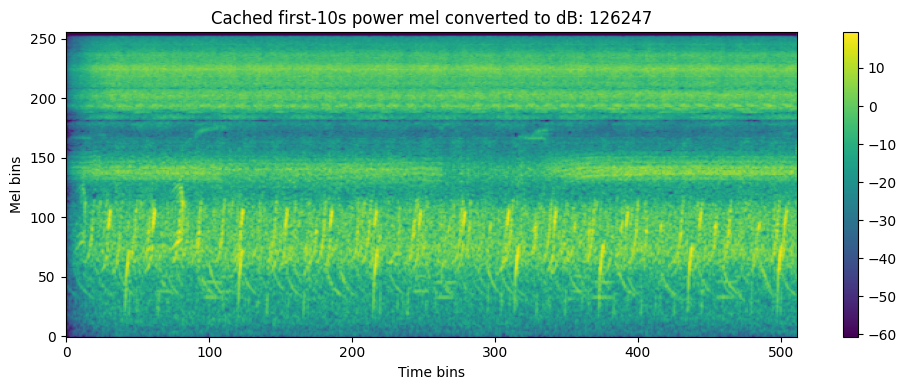

In [7]:
# ============================================================
# 7. Audio and mel-spectrogram cache utilities
# ============================================================
def read_audio(path, sr=32000):
    wav, file_sr = sf.read(str(path), dtype="float32", always_2d=False)
    if wav.ndim > 1:
        wav = np.mean(wav, axis=1)
    if file_sr != sr:
        wav = librosa.resample(wav, orig_sr=file_sr, target_sr=sr)
    return wav.astype(np.float32)

def crop_or_pad_wave(wav, target_len, random_crop=False):
    if len(wav) < target_len:
        return np.pad(wav, (0, target_len - len(wav)), mode="constant")
    if len(wav) == target_len:
        return wav
    start = np.random.randint(0, len(wav) - target_len + 1) if random_crop else 0
    return wav[start:start + target_len]

def compute_power_mel(wav, data_cfg: DataCfg, duration_seconds=None):
    # For cache, store power mel. The dataset later converts power -> dB, like the original code.
    if duration_seconds is not None:
        wav = crop_or_pad_wave(wav, int(duration_seconds * data_cfg.fs), random_crop=False)

    mel = librosa.feature.melspectrogram(
        y=wav,
        sr=data_cfg.fs,
        n_fft=data_cfg.n_fft,
        hop_length=data_cfg.hop_length,
        n_mels=data_cfg.n_mels,
        fmin=data_cfg.fmin,
        fmax=data_cfg.fmax,
        power=2.0,
    ).astype(np.float32)

    # The original cache corresponds to 5s -> target_shape[0] time bins.
    # For first10, use 10s -> 2 * target_shape[0] time bins.
    if duration_seconds is not None:
        target_time_bins = int(round(data_cfg.target_shape[0] * duration_seconds / data_cfg.target_duration))
        target_shape = (target_time_bins, data_cfg.n_mels)  # cv2 uses width x height
        mel = cv2.resize(mel, target_shape, interpolation=cv2.INTER_AREA)
    return mel.astype(np.float16)

def cache_dir_for(data_cfg: DataCfg, split_name="raw_data"):
    return Path(settings.data_cache_dir) / data_cfg.name / split_name

def build_spectrogram_cache(df, data_cfg: DataCfg, split_name="raw_data", max_files=None, overwrite=False):
    out_dir = cache_dir_for(data_cfg, split_name)
    out_dir.mkdir(parents=True, exist_ok=True)

    use_df = df.reset_index(drop=True)
    if max_files is not None:
        # Random sampling avoids caching only the first alphabetically sorted labels.
        use_df = use_df.sample(min(max_files, len(use_df)), random_state=42).reset_index(drop=True)

    print(f"Building cache: {data_cfg.name}/{split_name}")
    print("Rows:", len(use_df), "| output:", out_dir)

    duration = 10.0 if data_cfg.is_first10 else None
    made, skipped, failed = 0, 0, 0

    for _, row in tqdm(use_df.iterrows(), total=len(use_df), desc=f"cache {data_cfg.name}"):
        samplename = row["samplename"] if "samplename" in row else make_samplename(row["filename"])
        out_path = out_dir / f"{samplename}.npy"
        if out_path.exists() and not overwrite:
            skipped += 1
            continue
        try:
            wav = read_audio(Path(settings.train_datadir) / row["filename"], data_cfg.fs)
            mel = compute_power_mel(wav, data_cfg, duration_seconds=duration)
            np.save(out_path, mel)
            made += 1
        except Exception as e:
            failed += 1
            if failed <= 5:
                print("Failed:", row.get("filename", "?"), repr(e))

    print(f"Cache done. made={made}, skipped={skipped}, failed={failed}")
    return out_dir

def load_spectrogram_map(data_cfg: DataCfg, split_name="raw_data"):
    d = cache_dir_for(data_cfg, split_name)
    paths = sorted(d.glob("*.npy"))
    return {p.stem: str(p) for p in paths}

# Visual sanity check on one file.
example_row = cv_df_preview.iloc[0]
example_cfg = data_cfg_dict[_tmp_cfg.data_name]
example_wav = read_audio(Path(settings.train_datadir) / example_row["filename"], example_cfg.fs)
example_mel = compute_power_mel(example_wav, example_cfg, duration_seconds=10.0)
print("Example power mel:", example_mel.shape, example_mel.dtype, "from", example_row["filename"])

plt.figure(figsize=(10, 4))
plt.imshow(librosa.power_to_db(example_mel.astype(np.float32), ref=1.0), aspect="auto", origin="lower")
plt.title(f"Cached first-10s power mel converted to dB: {example_row['primary_label']}")
plt.xlabel("Time bins")
plt.ylabel("Mel bins")
plt.colorbar()
plt.tight_layout()
plt.show()

In [8]:
# ============================================================
# 8. Prepare data cache
# ============================================================
if RUN_PREPARE_DATA:
    needed_data_names = sorted({model_cfg_dict[v].data_name for v in SELECTED_CONFIGS})
    for data_name in needed_data_names:
        data_cfg = data_cfg_dict[data_name]

        # Build dataframe once with any selected config.
        cfg_for_df = model_cfg_dict[SELECTED_CONFIGS[0]]
        full_df_for_cache = train_df_raw.copy()
        full_df_for_cache["samplename"] = full_df_for_cache["filename"].map(make_samplename)

        max_cache_files = max([model_cfg_dict[v].max_cache_files for v in SELECTED_CONFIGS if model_cfg_dict[v].data_name == data_name], default=None)
        if RUN_MODE in ["report_train", "dylan_like_long"]:
            max_cache_files = None

        build_spectrogram_cache(
            full_df_for_cache,
            data_cfg,
            split_name="raw_data",
            max_files=max_cache_files,
            overwrite=False,
        )
else:
    print("RUN_PREPARE_DATA=False, skipping cache creation.")

if RUN_MODE == "cache_only":
    print("Cache-only mode complete. Stop here or switch RUN_MODE to report_train.")

Building cache: v1_first10/raw_data
Rows: 28564 | output: /kaggle/working/birdclef_dylan_like/data_cache/v1_first10/raw_data


cache v1_first10:   0%|          | 0/28564 [00:00<?, ?it/s]

Cache done. made=28564, skipped=0, failed=0


In [9]:
# ============================================================
# 9. Original-like NPY dataset with class resampling
# ============================================================
class BirdCLEFDatasetFromNPY(Dataset):
    def __init__(self, df, cfg: ModelCfg, data_cfg: DataCfg, spectrograms, mode="train"):
        self.df = df.reset_index(drop=True).copy()
        self.cfg = cfg
        self.data_cfg = data_cfg
        self.spectrograms = spectrograms
        self.mode = mode
        self.species_ids = species_ids
        self.num_classes = len(species_ids)

        if "samplename" not in self.df.columns:
            self.df["samplename"] = self.df["filename"].map(make_samplename)
        if "purename" not in self.df.columns:
            self.df["purename"] = self.df["filename"].map(lambda x: Path(x).stem)

        self.samplename_id_map = {name: i for i, name in enumerate(self.df["samplename"].values)}
        self.df_samplename_dict = {samplename: [] for samplename in self.df["samplename"].values}

        for name in self.spectrograms:
            if name in self.df_samplename_dict:
                self.df_samplename_dict[name].append(name)

        for k in self.df_samplename_dict:
            self.df_samplename_dict[k] = sorted(self.df_samplename_dict[k])

        if mode == "train":
            self.init_train_dataset()
        else:
            self.used_df_samplenames = [
                sn for sn in self.df["samplename"].values
                if len(self.df_samplename_dict.get(sn, [])) > 0
            ]
            print(f"Found {len(self.used_df_samplenames)} matching spectrograms for {mode} out of {len(self.df)} rows")

    def init_train_dataset(self):
        self.used_df_samplenames = []
        used_df = self.df[self.df.get("removed", 0) == 0] if "removed" in self.df.columns else self.df
        for label in self.species_ids:
            if "primary_label" in used_df.columns:
                names = used_df[used_df["primary_label"] == label]["samplename"].tolist()
            else:
                names = []
            names = [sn for sn in names if len(self.df_samplename_dict.get(sn, [])) > 0]
            if len(names) == 0:
                continue
            # Original idea: resample each primary class to a minimum count.
            if len(names) < self.cfg.min_samples_per_class:
                extra = np.random.choice(names, self.cfg.min_samples_per_class - len(names), replace=True).tolist()
                names = names + extra
            self.used_df_samplenames.extend(names)

        # Add pseudo/semi rows if present.
        semi_names = []
        if "primary_label" in used_df.columns:
            semi_names = used_df[used_df["primary_label"] == "semi"]["samplename"].tolist()
            semi_names = [sn for sn in semi_names if len(self.df_samplename_dict.get(sn, [])) > 0]
        self.used_df_samplenames.extend(semi_names)

        random.shuffle(self.used_df_samplenames)
        print(f"Training dataset rebuilt with {len(self.used_df_samplenames)} sampled items")

    def __len__(self):
        return len(self.used_df_samplenames)

    def _load_spec(self, samplename):
        path = self.spectrograms[samplename]
        spec = np.load(path, allow_pickle=True)
        if isinstance(spec, np.ndarray) and spec.dtype == object:
            try:
                spec = spec.item().get("spec", spec)
            except Exception:
                pass
        return spec.astype(np.float32)

    def _target_from_row(self, row):
        return row[self.species_ids].astype(np.float32).values

    def _crop_or_pad_spec(self, spec):
        # spec shape: [n_mels, time]
        low, high = self.cfg.data_train_duration_range
        if self.mode == "train":
            spec_len_sec = np.random.uniform(low, high)
        else:
            spec_len_sec = high
        target_len = int(round(spec_len_sec * self.data_cfg.target_shape[0] / self.data_cfg.target_duration))

        if spec.shape[-1] < target_len:
            pad = np.zeros((spec.shape[0], target_len - spec.shape[-1]), dtype=spec.dtype)
            if self.mode == "train":
                left = np.random.randint(0, pad.shape[-1] + 1)
            else:
                left = 0
            right = pad.shape[-1] - left
            spec = np.concatenate([np.zeros((spec.shape[0], left), dtype=spec.dtype), spec, np.zeros((spec.shape[0], right), dtype=spec.dtype)], axis=-1)
        elif spec.shape[-1] > target_len:
            if self.mode == "train":
                start = np.random.randint(0, spec.shape[-1] - target_len + 1)
            else:
                start = 0
            spec = spec[:, start:start + target_len]

        return spec

    def apply_spec_augmentations(self, spec):
        # spec: [1, mel, time]
        if random.random() < 0.5:
            for _ in range(random.randint(1, 3)):
                width = random.randint(5, min(24, max(6, spec.shape[2] // 8)))
                start = random.randint(0, max(0, spec.shape[2] - width))
                spec[0, :, start:start+width] = 0
        if random.random() < 0.5:
            for _ in range(random.randint(1, 3)):
                height = random.randint(5, min(24, max(6, spec.shape[1] // 8)))
                start = random.randint(0, max(0, spec.shape[1] - height))
                spec[0, start:start+height, :] = 0
        if random.random() < 0.5:
            gain = random.uniform(0.8, 1.2)
            spec = spec * gain
        return spec

    def __getitem__(self, idx):
        base_sn = self.used_df_samplenames[idx]
        candidates = self.df_samplename_dict[base_sn]
        samplename = np.random.choice(candidates) if self.mode == "train" else candidates[0]

        row = self.df.iloc[self.samplename_id_map[base_sn]]
        spec = self._load_spec(samplename)
        spec = self._crop_or_pad_spec(spec)

        # Original-like: convert cached power mel to dB during dataset loading.
        spec = librosa.power_to_db(spec, ref=1.0).astype(np.float32)

        # Stable normalization helps Kaggle report runs. Disable this line for stricter original reproduction.
        spec = (spec - spec.mean()) / (spec.std() + 1e-6)

        spec = torch.tensor(spec, dtype=torch.float32).unsqueeze(0)
        if self.mode == "train" and random.random() < self.cfg.aug_prob:
            spec = self.apply_spec_augmentations(spec)

        target = torch.tensor(self._target_from_row(row), dtype=torch.float32)
        weight = torch.tensor(1.0, dtype=torch.float32)

        return {
            "melspec": spec,
            "target": target,
            "weight": weight,
            "filename": row.get("filename", samplename),
            "samplename": base_sn,
        }

def collate_fn(batch):
    batch = [b for b in batch if b is not None]
    if len(batch) == 0:
        return {}
    return {
        "melspec": torch.stack([b["melspec"] for b in batch]),
        "target": torch.stack([b["target"] for b in batch]),
        "weight": torch.stack([b["weight"] for b in batch]),
        "filename": [b["filename"] for b in batch],
        "samplename": [b["samplename"] for b in batch],
    }

In [10]:
# ============================================================
# 10. Original-like SED model: EfficientNet + attention pooling
# ============================================================
def init_layer(layer):
    nn.init.xavier_uniform_(layer.weight)
    if hasattr(layer, "bias") and layer.bias is not None:
        layer.bias.data.fill_(0.0)

def init_bn(bn):
    bn.bias.data.fill_(0.0)
    bn.weight.data.fill_(1.0)

class AttBlock(nn.Module):
    def __init__(self, in_features: int, out_features: int, activation="linear", temperature=1.0):
        super().__init__()
        self.activation = activation
        self.temperature = temperature
        self.att = nn.Conv1d(in_features, out_features, kernel_size=1, stride=1, padding=0, bias=True)
        self.cla = nn.Conv1d(in_features, out_features, kernel_size=1, stride=1, padding=0, bias=True)
        self.bn_att = nn.BatchNorm1d(out_features)
        self.init_weights()

    def init_weights(self):
        init_layer(self.att)
        init_layer(self.cla)
        init_bn(self.bn_att)

    def nonlinear_transform(self, x):
        if self.activation == "linear":
            return x
        if self.activation == "sigmoid":
            return torch.sigmoid(x)
        raise ValueError(self.activation)

    def forward(self, x):
        # x: [B, C, T]
        norm_att = torch.softmax(torch.clamp(self.att(x), -10, 10), dim=-1)
        cla = self.nonlinear_transform(self.cla(x))
        clipwise = torch.sum(norm_att * cla, dim=2)
        return clipwise, norm_att, cla

class BirdCLEFModel(nn.Module):
    def __init__(self, cfg: ModelCfg, data_cfg: DataCfg, num_classes):
        super().__init__()
        self.cfg = cfg
        self.data_cfg = data_cfg
        self.num_classes = num_classes

        # Equivalent spirit to original bn0 = BatchNorm2d(TARGET_SHAPE[1]).
        self.bn0 = nn.BatchNorm2d(data_cfg.n_mels)

        self.encoder = timm.create_model(
            cfg.model_name,
            pretrained=cfg.pretrained,
            in_chans=cfg.in_channels,
            num_classes=0,
            global_pool="",
            drop_rate=cfg.drop_rate,
            drop_path_rate=cfg.drop_path_rate,
        )
        in_features = self.encoder.num_features

        self.fc1 = nn.Linear(in_features, in_features, bias=True)
        self.att_block = AttBlock(in_features, num_classes, activation="linear")
        self.init_weight()

    def init_weight(self):
        init_bn(self.bn0)
        init_layer(self.fc1)

    def forward(self, x):
        # x: [B, 1, mel, time]
        # Normalize across mel bins, original-style transpose around bn0.
        x = x.transpose(1, 2)  # [B, mel, 1, time]
        x = self.bn0(x)
        x = x.transpose(1, 2)  # [B, 1, mel, time]

        x = self.encoder(x)
        if isinstance(x, (list, tuple)):
            x = x[-1]

        if x.ndim != 4:
            raise RuntimeError(f"Expected 4D feature map from encoder, got {x.shape}")

        # Mean over frequency, keep time.
        x = torch.mean(x, dim=2)  # [B, C, T]

        # Original-like temporal smoothing.
        x1 = F.max_pool1d(x, kernel_size=3, stride=1, padding=1)
        x2 = F.avg_pool1d(x, kernel_size=3, stride=1, padding=1)
        x = x1 + x2

        x = F.dropout(x, p=self.cfg.dropout_rate, training=self.training)
        x = x.transpose(1, 2)
        x = F.relu_(self.fc1(x))
        x = x.transpose(1, 2)
        x = F.dropout(x, p=self.cfg.dropout_rate, training=self.training)

        clipwise_output, norm_att, framewise_output = self.att_block(x)
        return clipwise_output, framewise_output

In [11]:
# ============================================================
# 11. Original-like AUC losses
# ============================================================
class AUCLoss(nn.Module):
    def __init__(self, margin=1.0, pos_weight=1.0, neg_weight=1.0):
        super().__init__()
        self.margin = margin
        self.pos_weight = pos_weight
        self.neg_weight = neg_weight

    def forward(self, preds, labels, sample_weights=None):
        pos_preds = preds[labels == 1]
        neg_preds = preds[labels == 0]
        if len(pos_preds) == 0 or len(neg_preds) == 0:
            return torch.tensor(0.0, device=preds.device)

        if sample_weights is not None:
            expanded = torch.stack([sample_weights] * labels.shape[1], dim=1)
            pos_weights = expanded[labels == 1]
            neg_weights = expanded[labels == 0]
        else:
            pos_weights = torch.ones_like(pos_preds) * self.pos_weight
            neg_weights = torch.ones_like(neg_preds) * self.neg_weight

        diff = pos_preds.unsqueeze(1) - neg_preds.unsqueeze(0)
        loss_matrix = torch.log1p(torch.exp(-diff * self.margin))
        weighted = loss_matrix * pos_weights.unsqueeze(1) * neg_weights.unsqueeze(0)
        return weighted.mean()

class SoftAUCLoss(nn.Module):
    def __init__(self, margin=1.0, pos_weight=1.0, neg_weight=1.0):
        super().__init__()
        self.margin = margin
        self.pos_weight = pos_weight
        self.neg_weight = neg_weight

    def forward(self, preds, labels, sample_weights=None):
        pos_mask = labels > 0.5
        neg_mask = labels < 0.5
        pos_preds = preds[pos_mask]
        neg_preds = preds[neg_mask]
        pos_labels = labels[pos_mask]
        neg_labels = labels[neg_mask]

        if len(pos_preds) == 0 or len(neg_preds) == 0:
            return torch.tensor(0.0, device=preds.device)

        pos_weights = torch.ones_like(pos_preds) * self.pos_weight * (pos_labels - 0.5)
        neg_weights = torch.ones_like(neg_preds) * self.neg_weight * (0.5 - neg_labels)

        if sample_weights is not None:
            expanded = torch.stack([sample_weights] * labels.shape[1], dim=1)
            pos_weights = pos_weights * expanded[pos_mask]
            neg_weights = neg_weights * expanded[neg_mask]

        diff = pos_preds.unsqueeze(1) - neg_preds.unsqueeze(0)
        loss_matrix = torch.log1p(torch.exp(-diff * self.margin))
        weighted = loss_matrix * pos_weights.unsqueeze(1) * neg_weights.unsqueeze(0)
        return weighted.mean()

def get_criterion(cfg: ModelCfg):
    criterions = []
    for name in cfg.criterions:
        if name == "AUCLoss":
            criterions.append(AUCLoss(margin=cfg.auc_margin))
        elif name == "SoftAUCLoss":
            criterions.append(SoftAUCLoss(margin=cfg.auc_margin))
        elif name == "BCE":
            criterions.append(nn.BCEWithLogitsLoss())
        else:
            raise NotImplementedError(name)

    bce_anchor = nn.BCEWithLogitsLoss(reduction="mean")

    def combined_loss(outputs, targets, weights=None):
        loss = sum([criterion(outputs, targets, weights) if isinstance(criterion, (AUCLoss, SoftAUCLoss)) else criterion(outputs, targets)
                    for criterion in criterions]) / len(criterions)
        parts = {"auc_rank_loss": loss.detach()}

        if cfg.use_bce_anchor:
            bce = bce_anchor(outputs, targets)
            loss = loss + cfg.bce_anchor_weight * bce
            parts["bce_anchor"] = bce.detach()

        return loss, parts

    return combined_loss

def calculate_auc(targets, outputs):
    probs = 1 / (1 + np.exp(-outputs))
    aucs = []
    for i in range(targets.shape[1]):
        if np.sum(targets[:, i] > 0) > 0 and np.sum(targets[:, i] > 0) < len(targets):
            try:
                aucs.append(roc_auc_score((targets[:, i] > 0.0).astype(int), probs[:, i]))
            except Exception:
                aucs.append(np.nan)
        else:
            aucs.append(np.nan)
    valid = [a for a in aucs if not np.isnan(a)]
    return aucs, float(np.mean(valid)) if valid else np.nan, len(valid)

def print_probability_stats(logits, prefix="valid"):
    probs = 1 / (1 + np.exp(-logits))
    print(f"{prefix} probs shape:", probs.shape)
    print(f"{prefix} probs min/mean/max: {probs.min():.6f} / {probs.mean():.6f} / {probs.max():.6f}")
    print(f"{prefix} pct > 0.01: {(probs > 0.01).mean():.6f}")
    print(f"{prefix} pct > 0.10: {(probs > 0.10).mean():.6f}")
    return probs

In [12]:
# ============================================================
# 12. Train/validation functions
# ============================================================
def get_optimizer(model, cfg: ModelCfg):
    if cfg.optimizer == "AdamW":
        return optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
    if cfg.optimizer == "Adam":
        return optim.Adam(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
    if cfg.optimizer == "SGD":
        return optim.SGD(model.parameters(), lr=cfg.lr, momentum=0.9, weight_decay=cfg.weight_decay)
    raise NotImplementedError(cfg.optimizer)

def get_scheduler(optimizer, cfg: ModelCfg):
    if cfg.scheduler == "CosineAnnealingLR":
        return lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(1, cfg.epochs), eta_min=cfg.min_lr)
    if cfg.scheduler == "OneCycleLR":
        return None
    return None

def mixup_batch(inputs, targets, weights, cfg: ModelCfg):
    if cfg.mixup_alpha <= 0 or random.random() > cfg.mixup_rate:
        return inputs, targets, weights, None
    lam = np.random.beta(cfg.mixup_alpha, cfg.mixup_alpha)
    index = torch.randperm(inputs.size(0), device=inputs.device)
    mixed_inputs = lam * inputs + (1 - lam) * inputs[index]
    return mixed_inputs, targets, weights, (index, lam)

def train_one_epoch(model, loader, optimizer, criterion, scaler, cfg: ModelCfg, scheduler=None):
    model.train()
    loader.dataset.init_train_dataset()

    losses = []
    all_outputs = []
    all_targets = []

    pbar = tqdm(loader, desc="train")
    for batch in pbar:
        inputs = batch["melspec"].to(cfg.device, non_blocking=True)
        targets = batch["target"].to(cfg.device, non_blocking=True)
        weights = batch["weight"].to(cfg.device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=cfg.apex):
            inputs_mixed, targets_mixed, weights_mixed, mix_info = mixup_batch(inputs, targets, weights, cfg)
            outputs, _ = model(inputs_mixed)

            if mix_info is None:
                loss, parts = criterion(outputs, targets_mixed, weights_mixed)
            else:
                index, lam = mix_info
                loss1, _ = criterion(outputs, targets, weights)
                loss2, _ = criterion(outputs, targets[index], weights[index])
                loss = lam * loss1 + (1 - lam) * loss2

        scaler.scale(loss).backward()
        if cfg.max_grad_norm is not None:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.max_grad_norm)
        scaler.step(optimizer)
        scaler.update()

        if scheduler is not None and isinstance(scheduler, lr_scheduler.OneCycleLR):
            scheduler.step()

        losses.append(float(loss.detach().cpu()))
        all_outputs.append(outputs.detach().cpu().numpy())
        all_targets.append(targets.detach().cpu().numpy())
        pbar.set_postfix(loss=np.mean(losses))

    all_outputs = np.concatenate(all_outputs, axis=0)
    all_targets = np.concatenate(all_targets, axis=0)
    _, train_auc, n_auc = calculate_auc(all_targets, all_outputs)
    return float(np.mean(losses)), train_auc, n_auc

@torch.no_grad()
def validate(model, loader, criterion, cfg: ModelCfg):
    model.eval()
    losses = []
    sample_losses = []
    all_outputs = []
    all_targets = []
    all_samplenames = []

    bce_sample = nn.BCEWithLogitsLoss(reduction="none")

    for batch in tqdm(loader, desc="valid"):
        inputs = batch["melspec"].to(cfg.device, non_blocking=True)
        targets = batch["target"].to(cfg.device, non_blocking=True)
        weights = batch["weight"].to(cfg.device, non_blocking=True)

        with torch.cuda.amp.autocast(enabled=cfg.apex):
            outputs, _ = model(inputs)
            loss, _ = criterion(outputs, targets, weights)

        losses.append(float(loss.detach().cpu()))
        sample_losses.append(bce_sample(outputs, targets).mean(dim=1).detach().cpu().numpy())
        all_outputs.append(outputs.detach().cpu().numpy())
        all_targets.append(targets.detach().cpu().numpy())
        all_samplenames.extend(batch["samplename"])

    all_outputs = np.concatenate(all_outputs, axis=0)
    all_targets = np.concatenate(all_targets, axis=0)
    sample_losses = np.concatenate(sample_losses, axis=0)
    aucs, val_auc, n_auc = calculate_auc(all_targets, all_outputs)

    return {
        "valid_loss": float(np.mean(losses)),
        "valid_auc": val_auc,
        "valid_auc_classes": n_auc,
    }, aucs, all_outputs, all_targets, sample_losses, all_samplenames

In [13]:
# ============================================================
# 13. One-version training runner
# ============================================================

def build_semi_dataframe(semi_csv_path, cfg: ModelCfg):
    semi_path = Path(semi_csv_path)
    assert semi_path.exists(), f"Pseudo-label CSV not found: {semi_path}"

    semi_df = pd.read_csv(semi_path)
    semi_df["samplename"] = semi_df["row_id"]
    semi_df["purename"] = semi_df["row_id"]
    semi_df["primary_label"] = "semi"
    semi_df["filename"] = semi_df["row_id"]
    semi_df["removed"] = 0

    # Original-like min-max normalization per label.
    for label in species_ids:
        mn, mx = semi_df[label].min(), semi_df[label].max()
        if mx > mn:
            semi_df[label] = (semi_df[label] - mn) / (mx - mn)
        else:
            semi_df[label] = 0.0

    label_sums = semi_df[species_ids].values.sum(axis=1)
    cutoff = np.quantile(label_sums, cfg.semi_drop)
    semi_df.loc[label_sums <= cutoff, "removed"] = 1

    print("Semi rows:", len(semi_df), "| removed:", int(semi_df["removed"].sum()), "| cutoff:", cutoff)
    return semi_df


def build_loaders_for_config(cfg: ModelCfg):
    set_seed(cfg.seed)
    data_cfg = data_cfg_dict[cfg.data_name]
    # Attach dynamic field used by dataset.
    cfg.data_train_duration_range = data_cfg.train_duration_range

    cv_df, extra_train_df, _ = build_train_dataframe(train_df_raw, cfg)

    # Load cached spectrograms.
    train_spectrograms = load_spectrogram_map(data_cfg, split_name="raw_data")

    # Optional semi-supervised cache. This mirrors the raw_semi_data idea in the original repo.
    semi_df = None
    semi_csv = Path(cfg.semi_train_csv) if cfg.semi_train_csv else Path(settings.data_cache_dir) / "semi_train_preds.csv"
    if semi_csv.exists():
        try:
            semi_df = build_semi_dataframe(semi_csv, cfg)
            semi_specs = load_spectrogram_map(data_cfg, split_name="raw_semi_data")
            train_spectrograms.update(semi_specs)
            print("Loaded semi spectrograms:", len(semi_specs))
        except Exception as e:
            print("Semi data was found but not used:", repr(e))
            semi_df = None

    print("Loaded cached spectrograms:", len(train_spectrograms), "for", data_cfg.name)
    assert len(train_spectrograms) > 0, "No cached spectrograms found. Run prepare-data cells first."

    # Keep rows that have cached spectrogram.
    cv_df = cv_df[cv_df["samplename"].isin(train_spectrograms)].reset_index(drop=True)
    extra_train_df = extra_train_df[extra_train_df["samplename"].isin(train_spectrograms)].reset_index(drop=True)

    if cfg.max_train_rows is not None:
        # Limit before split for quick debug. Add a validation budget if present.
        budget = cfg.max_train_rows + (cfg.max_valid_rows or 0)
        cv_df = cv_df.sample(min(budget, len(cv_df)), random_state=cfg.seed).reset_index(drop=True)

    # Robust fold construction after cache filtering/subsampling.
    label_counts_after_cache = cv_df["primary_label"].value_counts()
    if len(label_counts_after_cache) == 0:
        raise RuntimeError("No CV rows with cached spectrograms. Increase max_cache_files or rebuild cache.")
    actual_n_fold = min(cfg.n_fold, int(label_counts_after_cache.min()))
    loaders = []

    if actual_n_fold >= 2:
        print(f"Using StratifiedKFold with n_splits={actual_n_fold} after cache filtering.")
        skf = StratifiedKFold(n_splits=actual_n_fold, shuffle=True, random_state=cfg.fold_seed)
        folds = list(skf.split(cv_df, cv_df["primary_label"]))
    else:
        print("Fallback random 80/20 split because some cached classes have <2 samples.")
        shuffled = cv_df.sample(frac=1.0, random_state=cfg.fold_seed).reset_index(drop=True)
        split = max(1, int(0.8 * len(shuffled)))
        folds = [(np.arange(split), np.arange(split, len(shuffled)))]

    for fold, (train_idx, val_idx) in enumerate(folds):
        if actual_n_fold >= 2 and fold not in cfg.selected_folds:
            continue

        train_df = cv_df.iloc[train_idx].reset_index(drop=True)
        val_df = cv_df.iloc[val_idx].reset_index(drop=True)

        if cfg.max_train_rows is not None:
            train_df = train_df.sample(min(cfg.max_train_rows, len(train_df)), random_state=cfg.seed + fold).reset_index(drop=True)
        if cfg.max_valid_rows is not None:
            val_df = val_df.sample(min(cfg.max_valid_rows, len(val_df)), random_state=cfg.seed + 1000 + fold).reset_index(drop=True)

        if len(extra_train_df) > 0:
            train_df = pd.concat([train_df, extra_train_df], ignore_index=True)

        # Add pseudo-labeled rows only to the training split, not validation.
        if semi_df is not None and len(semi_df) > 0:
            semi_train_df = semi_df[(semi_df["removed"] == 0) & (semi_df["samplename"].isin(train_spectrograms))].reset_index(drop=True)
            train_df = pd.concat([train_df, semi_train_df], ignore_index=True)
            print(f"Added semi rows to train fold {fold}: {len(semi_train_df)}")

        print(f"Fold {fold}: train rows={len(train_df)}, valid rows={len(val_df)}")

        train_dataset = BirdCLEFDatasetFromNPY(train_df, cfg, data_cfg, train_spectrograms, mode="train")
        val_dataset = BirdCLEFDatasetFromNPY(val_df, cfg, data_cfg, train_spectrograms, mode="valid")

        train_loader = DataLoader(
            train_dataset,
            batch_size=cfg.batch_size,
            shuffle=True,
            num_workers=cfg.num_workers,
            pin_memory=(cfg.device == "cuda" and cfg.num_workers > 0),
            collate_fn=collate_fn,
            drop_last=False,
        )
        val_loader = DataLoader(
            val_dataset,
            batch_size=cfg.valid_batch_size,
            shuffle=False,
            num_workers=cfg.num_workers,
            pin_memory=(cfg.device == "cuda" and cfg.num_workers > 0),
            collate_fn=collate_fn,
        )
        loaders.append((fold, train_loader, val_loader, train_df, val_df, data_cfg))

    return loaders

def run_training_for_config(version):
    cfg = model_cfg_dict[version]
    cfg.device = "cuda" if torch.cuda.is_available() else "cpu"
    data_cfg = data_cfg_dict[cfg.data_name]

    print("=" * 80)
    print("Training version:", version)
    print("Model:", cfg.model_name, "| Data:", cfg.data_name, "| Device:", cfg.device)
    print("=" * 80)

    ckpt_path = Path(settings.model_dir) / f"{version}.pth"
    history_path = Path(settings.output_dir) / f"history_{version}.csv"
    cvpred_path = Path(settings.output_dir) / f"cv_preds_{version}.csv"

    if ckpt_path.exists() and cfg.reuse_existing_checkpoint and RUN_MODE != "dylan_like_long":
        print("Checkpoint exists and reuse is enabled. Loading:", ckpt_path)
        return {"version": version, "checkpoint": str(ckpt_path), "skipped": True}

    loaders = build_loaders_for_config(cfg)
    best_scores = []
    all_cv_pred_rows = []
    full_history = []

    for fold, train_loader, val_loader, train_df, val_df, data_cfg in loaders:
        print(f"\n{'='*30} Fold {fold} {'='*30}")
        set_seed(cfg.seed + fold)

        model = BirdCLEFModel(cfg, data_cfg, num_classes=len(species_ids)).to(cfg.device)
        optimizer = get_optimizer(model, cfg)
        criterion = get_criterion(cfg)
        scaler = torch.cuda.amp.GradScaler(enabled=cfg.apex)
        scheduler = get_scheduler(optimizer, cfg)
        swa_model = AveragedModel(model)

        best_auc = -1
        best_epoch = -1
        last_outputs = None
        last_targets = None
        last_losses = None
        last_samplenames = None

        for epoch in range(cfg.epochs):
            print(f"\nEpoch {epoch+1}/{cfg.epochs}")
            train_loss, train_auc, train_auc_classes = train_one_epoch(
                model, train_loader, optimizer, criterion, scaler, cfg,
                scheduler if isinstance(scheduler, lr_scheduler.OneCycleLR) else None
            )

            if scheduler is not None and not isinstance(scheduler, lr_scheduler.OneCycleLR):
                scheduler.step()

            if epoch + 1 >= cfg.acc_start_epoch:
                swa_model.update_parameters(model)

            valid_log, val_aucs, outputs, targets, sample_losses, samplenames = validate(model, val_loader, criterion, cfg)
            probs = print_probability_stats(outputs, prefix=f"fold{fold}_epoch{epoch+1}")

            low_ids = np.argsort(np.nan_to_num(val_aucs, nan=999.0))[:10]
            low_auc_classes = {species_ids[i]: float(val_aucs[i]) if not np.isnan(val_aucs[i]) else None for i in low_ids}

            row = {
                "version": version,
                "fold": fold,
                "epoch": epoch + 1,
                "train_loss": train_loss,
                "train_auc": train_auc,
                "train_auc_classes": train_auc_classes,
                **valid_log,
                "lr": optimizer.param_groups[0]["lr"],
            }
            full_history.append(row)
            print(row)
            print("10 lowest AUC classes:", low_auc_classes)

            if not np.isnan(valid_log["valid_auc"]) and valid_log["valid_auc"] > best_auc:
                best_auc = valid_log["valid_auc"]
                best_epoch = epoch + 1
                torch.save({
                    "model_state_dict": model.state_dict(),
                    "version": version,
                    "cfg": {k: str(v) for k, v in asdict(cfg).items()},
                    "data_cfg": asdict(data_cfg),
                    "species_ids": species_ids,
                    "best_auc": best_auc,
                    "best_epoch": best_epoch,
                }, ckpt_path)
                print("Saved best checkpoint:", ckpt_path)

                last_outputs, last_targets = outputs, targets
                last_losses, last_samplenames = sample_losses, samplenames

        best_scores.append(best_auc)
        print(f"Best fold {fold} AUC: {best_auc:.5f} at epoch {best_epoch}")

        # Save CV predictions for report analysis.
        if last_outputs is not None:
            pred_probs = 1 / (1 + np.exp(-last_outputs))
            pred_dict = {"samplename": last_samplenames, "loss": last_losses}
            for i, label in enumerate(species_ids):
                pred_dict[label] = pred_probs[:, i]
                pred_dict[f"target_{label}"] = last_targets[:, i]
            fold_pred_df = pd.DataFrame(pred_dict)
            fold_pred_df["fold"] = fold
            all_cv_pred_rows.append(fold_pred_df)

        del model, optimizer, scheduler, train_loader, val_loader
        torch.cuda.empty_cache()
        gc.collect()

    hist_df = pd.DataFrame(full_history)
    hist_df.to_csv(history_path, index=False)
    print("Saved history:", history_path)

    if all_cv_pred_rows:
        cv_pred_df = pd.concat(all_cv_pred_rows, ignore_index=True)
        cv_pred_df.to_csv(cvpred_path, index=False)
        print("Saved CV predictions:", cvpred_path)

    print("Mean best AUC:", np.mean(best_scores) if best_scores else None)
    return {"version": version, "checkpoint": str(ckpt_path), "history": str(history_path), "best_scores": best_scores}

In [14]:
# ============================================================
# 14. Run selected training configs
# ============================================================
training_results = []

if RUN_TRAINING and RUN_MODE not in ["cache_only", "inference_only"]:
    for version in SELECTED_CONFIGS:
        result = run_training_for_config(version)
        training_results.append(result)
else:
    print("Training is disabled.")

training_results

Training version: tf_efficientnet_lite0_v1_first10
Model: tf_efficientnet_lite0 | Data: v1_first10 | Device: cuda
All labeled rows: 28564
CV rows: 27542
Extra rare rows: 1022
Labels with enough CV samples: 130
Loaded cached spectrograms: 28564 for v1_first10
Fallback random 80/20 split because some cached classes have <2 samples.
Fold 0: train rows=23055, valid rows=5509
Training dataset rebuilt with 30538 sampled items
Found 5509 matching spectrograms for valid out of 5509 rows

============================== Fold 0 ==============================

Epoch 1/13
Training dataset rebuilt with 30538 sampled items


train:   0%|          | 0/1909 [00:00<?, ?it/s]

valid:   0%|          | 0/173 [00:00<?, ?it/s]

fold0_epoch1 probs shape: (5509, 206)
fold0_epoch1 probs min/mean/max: 0.000004 / 0.043938 / 0.239418
fold0_epoch1 pct > 0.01: 0.918612
fold0_epoch1 pct > 0.10: 0.069270
{'version': 'tf_efficientnet_lite0_v1_first10', 'fold': 0, 'epoch': 1, 'train_loss': 0.17296119936243784, 'train_auc': 0.49541365136968313, 'train_auc_classes': 205, 'valid_loss': 0.4287585939544474, 'valid_auc': 0.5381970754630473, 'valid_auc_classes': 99, 'lr': 0.0004927499834478}
10 lowest AUC classes: {'fotfly': 0.04139433551198257, 'strher': 0.07298474945533773, 'blcjay1': 0.15722585330428462, 'colcha1': 0.212002905393136, 'cattyr': 0.246322861812239, 'rtlhum': 0.2588961510530138, 'cargra1': 0.28947915043880146, 'gybmar': 0.30007263482840024, 'paltan1': 0.3342574077440466, 'recwoo1': 0.3357549340113815}
Saved best checkpoint: /kaggle/working/birdclef_dylan_like/models/tf_efficientnet_lite0_v1_first10.pth

Epoch 2/13
Training dataset rebuilt with 30538 sampled items


train:   0%|          | 0/1909 [00:00<?, ?it/s]

...

fold0_epoch12 probs shape: (5509, 206)
fold0_epoch12 probs min/mean/max: 0.000000 / 0.015251 / 0.421813
fold0_epoch12 pct > 0.01: 0.419235
fold0_epoch12 pct > 0.10: 0.014152
{'version': 'tf_efficientnet_lite0_v1_first10', 'fold': 0, 'epoch': 12, 'train_loss': 0.08091611288109332, 'train_auc': 0.7189290221883278, 'train_auc_classes': 205, 'valid_loss': 0.35775687956827223, 'valid_auc': 0.6342800311667002, 'valid_auc_classes': 99, 'lr': 8.250016552200022e-06}
10 lowest AUC classes: {'strfly1': 0.09749455337690627, 'strher': 0.1263616557734205, 'mastit1': 0.24051207554022158, 'greibi1': 0.3371163973125113, 'blcjay1': 0.35457516339869277, 'whttro1': 0.3732631757857314, 'palhor2': 0.382612907131614, 'gybmar': 0.41274741238423823, 'rebbla1': 0.4344589687726943, 'whtdov': 0.44094389035162573}
Saved best checkpoint: /kaggle/working/birdclef_dylan_like/models/tf_efficientnet_lite0_v1_first10.pth

Epoch 13/13
Training dataset rebuilt with 30538 sampled items


train:   0%|          | 0/1909 [00:00<?, ?it/s]

valid:   0%|          | 0/173 [00:00<?, ?it/s]

fold0_epoch13 probs shape: (5509, 206)
fold0_epoch13 probs min/mean/max: 0.000000 / 0.014906 / 0.375862
fold0_epoch13 pct > 0.01: 0.409266
fold0_epoch13 pct > 0.10: 0.013980
{'version': 'tf_efficientnet_lite0_v1_first10', 'fold': 0, 'epoch': 13, 'train_loss': 0.08042202894895441, 'train_auc': 0.7184310890872229, 'train_auc_classes': 205, 'valid_loss': 0.3528026667978033, 'valid_auc': 0.6325713264674988, 'valid_auc_classes': 99, 'lr': 1e-06}
10 lowest AUC classes: {'strfly1': 0.09495279593318806, 'strher': 0.20279593318809008, 'mastit1': 0.24033048846922095, 'greibi1': 0.35046304703105136, 'whttro1': 0.35639420421228557, 'rebbla1': 0.39324618736383443, 'palhor2': 0.39865601162368325, 'blcjay1': 0.41267247639796656, 'gybmar': 0.4162883602687489, 'strcuc1': 0.438040404040404}
Best fold 0 AUC: 0.63428 at epoch 12
Saved history: /kaggle/working/birdclef_dylan_like/output/history_tf_efficientnet_lite0_v1_first10.csv
Saved CV predictions: /kaggle/working/birdclef_dylan_like/output/cv_preds_tf

[{'version': 'tf_efficientnet_lite0_v1_first10',
  'checkpoint': '/kaggle/working/birdclef_dylan_like/models/tf_efficientnet_lite0_v1_first10.pth',
  'history': '/kaggle/working/birdclef_dylan_like/output/history_tf_efficientnet_lite0_v1_first10.csv',
  'best_scores': [0.6342800311667002]}]

,version,fold,epoch,train_loss,train_auc,train_auc_classes,valid_loss,valid_auc,valid_auc_classes,lr
0,tf_efficientnet_lite0_v1_first10,0,1,0.172961,0.495414,205,0.428759,0.538197,99,0.000493
1,tf_efficientnet_lite0_v1_first10,0,2,0.144983,0.532835,205,0.388516,0.567301,99,0.000471
2,tf_efficientnet_lite0_v1_first10,0,3,0.132594,0.568115,205,0.373634,0.537642,99,0.000437
3,tf_efficientnet_lite0_v1_first10,0,4,0.119633,0.610946,205,0.366682,0.593494,99,0.000392
4,tf_efficientnet_lite0_v1_first10,0,5,0.109745,0.640712,205,0.347459,0.609443,99,0.000339
5,tf_efficientnet_lite0_v1_first10,0,6,0.102477,0.654824,205,0.350704,0.603424,99,0.000281
6,tf_efficientnet_lite0_v1_first10,0,7,0.096355,0.674573,205,0.340281,0.612147,99,0.000220
7,tf_efficientnet_lite0_v1_first10,0,8,0.091815,0.686037,205,0.342098,0.599317,99,0.000162
8,tf_efficientnet_lite0_v1_first10,0,9,0.087616,0.686061,205,0.353459,0.611621,99,0.000109
9,tf_efficientnet_lite0_v1_first10,0,10,0.084836,0.703619,205,0.349927,0.621901,99,0.000064


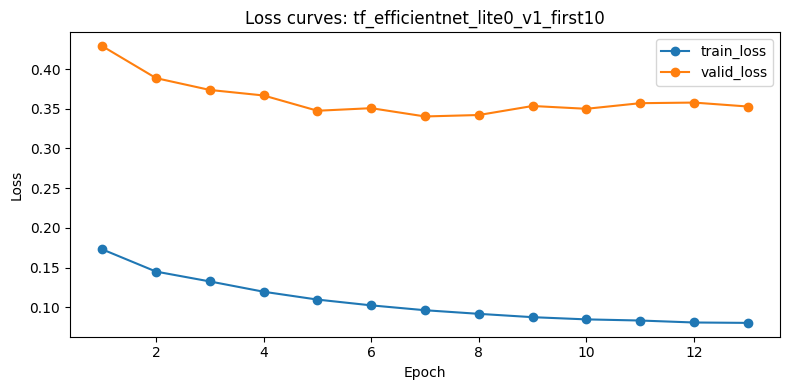

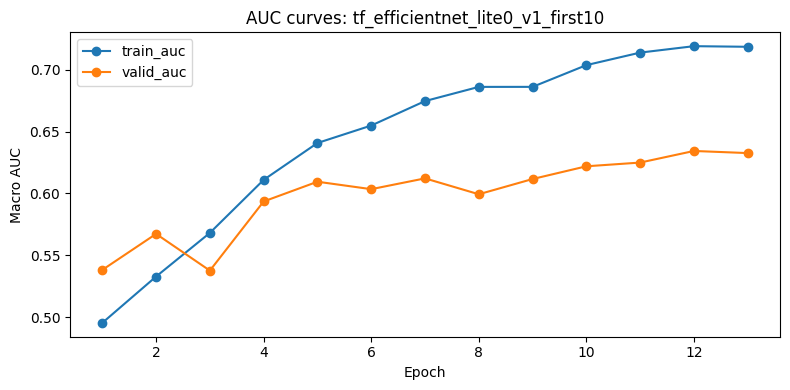

,samplename,true_labels,top_predictions,hit_top5
0,trokin-iNat1279601,trokin,"socfly1:0.1126, trokin:0.0985, grekis:0.0952, ...",True
1,trokin-iNat1284741,trokin,"grekis:0.1429, socfly1:0.1080, bbwduc:0.0866, ...",False
2,trokin-iNat128487,trokin,"grekis:0.1636, socfly1:0.1181, trokin:0.1017, ...",True
3,trokin-iNat1286058,trokin,"socfly1:0.1213, amekes:0.1000, solsan:0.0858, ...",True
4,trokin-iNat1287012,trokin,"banana:0.1370, trokin:0.1320, blbgra1:0.1097, ...",True
5,trokin-iNat1287369,trokin,"grekis:0.1512, socfly1:0.1448, sobtyr1:0.0988,...",True
6,trokin-iNat1287371,trokin,"amekes:0.0800, banana:0.0741, trokin:0.0590, s...",True
7,trokin-iNat1287382,trokin,"grekis:0.0678, sobtyr1:0.0650, socfly1:0.0611,...",True
8,trokin-iNat1287626,trokin,"grekis:0.1104, bbwduc:0.0950, sobtyr1:0.0772, ...",False
9,trokin-iNat1289580,trokin,"banana:0.2680, blbgra1:0.1841, trokin:0.1657, ...",True


Saved: /kaggle/working/birdclef_dylan_like/output/validation_top5_tf_efficientnet_lite0_v1_first10.csv
Hit@top5 in displayed rows: 0.8333333333333334


In [16]:
# ============================================================
# 15. Report plots and qualitative validation table
# ============================================================
def plot_history(version):
    history_path = Path(settings.output_dir) / f"history_{version}.csv"
    if not history_path.exists():
        print("No history found:", history_path)
        return None
    hist = pd.read_csv(history_path)
    display(hist)

    plt.figure(figsize=(8, 4))
    for col in ["train_loss", "valid_loss"]:
        if col in hist.columns:
            plt.plot(hist["epoch"], hist[col], marker="o", label=col)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Loss curves: {version}")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 4))
    for col in ["train_auc", "valid_auc"]:
        if col in hist.columns:
            plt.plot(hist["epoch"], hist[col], marker="o", label=col)
    plt.xlabel("Epoch")
    plt.ylabel("Macro AUC")
    plt.title(f"AUC curves: {version}")
    plt.legend()
    plt.tight_layout()
    plt.show()
    return hist

def make_topk_from_cvpred(version, k=5, n=30):
    cvpred_path = Path(settings.output_dir) / f"cv_preds_{version}.csv"
    if not cvpred_path.exists():
        print("No CV prediction file found:", cvpred_path)
        return None

    df = pd.read_csv(cvpred_path)
    rows = []
    pred_cols = species_ids
    target_cols = [f"target_{x}" for x in species_ids]

    for i in range(min(n, len(df))):
        pred = df.loc[i, pred_cols].values.astype(float)
        target = df.loc[i, target_cols].values.astype(float)
        true_labels = [species_ids[j] for j in np.where(target > 0.5)[0]]
        top_idx = np.argsort(pred)[::-1][:k]
        rows.append({
            "samplename": df.loc[i, "samplename"],
            "true_labels": ", ".join(true_labels),
            "top_predictions": ", ".join([f"{species_ids[j]}:{pred[j]:.4f}" for j in top_idx]),
            "hit_top5": any(j in top_idx for j in np.where(target > 0.5)[0]),
        })

    top_df = pd.DataFrame(rows)
    display(top_df)
    out_path = Path(settings.output_dir) / f"validation_top{k}_{version}.csv"
    top_df.to_csv(out_path, index=False)
    print("Saved:", out_path)
    print("Hit@top5 in displayed rows:", top_df["hit_top5"].mean() if len(top_df) else None)
    return top_df

for version in SELECTED_CONFIGS:
    plot_history(version)
    make_topk_from_cvpred(version, k=5, n=30)

In [ ]:
# ============================================================
# 16. Pseudo-label generation from soundscapes
# ============================================================
@torch.no_grad()
def load_trained_model(version):
    cfg = model_cfg_dict[version]
    data_cfg = data_cfg_dict[cfg.data_name]
    ckpt_path = Path(settings.model_dir) / f"{version}.pth"
    assert ckpt_path.exists(), f"Checkpoint not found: {ckpt_path}"

    model = BirdCLEFModel(cfg, data_cfg, num_classes=len(species_ids)).to(cfg.device)
    ckpt = torch.load(ckpt_path, map_location=cfg.device)
    model.load_state_dict(ckpt["model_state_dict"] if "model_state_dict" in ckpt else ckpt)
    model.eval()
    return model, cfg, data_cfg

def predict_wave_segments(model, wav, cfg: ModelCfg, data_cfg: DataCfg, segment_seconds=5.0):
    seg_len = int(segment_seconds * data_cfg.fs)
    n_segments = max(1, math.ceil(len(wav) / seg_len))
    logits_all = []

    for s in range(n_segments):
        seg = wav[s * seg_len:(s + 1) * seg_len]
        seg = crop_or_pad_wave(seg, seg_len, random_crop=False)

        # 5s segment -> target_shape[0] time bins.
        mel = compute_power_mel(seg, data_cfg, duration_seconds=segment_seconds)
        mel = librosa.power_to_db(mel.astype(np.float32), ref=1.0)
        mel = (mel - mel.mean()) / (mel.std() + 1e-6)
        x = torch.tensor(mel, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(cfg.device)

        with torch.cuda.amp.autocast(enabled=cfg.apex):
            logits, _ = model(x)
        logits_all.append(logits.detach().cpu().numpy()[0])

    return np.stack(logits_all, axis=0)


def build_soundscape_segment_cache(soundscape_dir, data_cfg: DataCfg, split_name="raw_semi_data", max_files=None, segment_seconds=5.0, overwrite=False):
    """Cache train/test soundscape segments as row_id.npy files.

    The row_id convention is <soundscape_stem>_<end_second>, matching pseudo-label CSV rows.
    """
    soundscape_dir = Path(soundscape_dir)
    out_dir = cache_dir_for(data_cfg, split_name)
    out_dir.mkdir(parents=True, exist_ok=True)

    files = sorted(list(soundscape_dir.glob("*.ogg")) + list(soundscape_dir.glob("*.wav")))
    if max_files is not None:
        files = files[:max_files]

    made, skipped, failed = 0, 0, 0
    for path in tqdm(files, desc=f"cache {split_name}"):
        try:
            wav = read_audio(path, data_cfg.fs)
            seg_len = int(segment_seconds * data_cfg.fs)
            n_segments = max(1, math.ceil(len(wav) / seg_len))
            for i in range(n_segments):
                end_sec = int((i + 1) * segment_seconds)
                row_id = f"{path.stem}_{end_sec}"
                out_path = out_dir / f"{row_id}.npy"
                if out_path.exists() and not overwrite:
                    skipped += 1
                    continue
                seg = wav[i * seg_len:(i + 1) * seg_len]
                seg = crop_or_pad_wave(seg, seg_len, random_crop=False)
                mel = compute_power_mel(seg, data_cfg, duration_seconds=segment_seconds)
                np.save(out_path, mel.astype(np.float16))
                made += 1
        except Exception as e:
            failed += 1
            if failed <= 5:
                print("Failed soundscape:", path.name, repr(e))
    print(f"Soundscape segment cache done. made={made}, skipped={skipped}, failed={failed}, out={out_dir}")
    return out_dir


def generate_pseudo_labels(version, max_files=None, segment_seconds=5.0):
    soundscape_dir = Path(settings.train_soundscapes)
    if not soundscape_dir.exists():
        print("train_soundscapes directory not found; pseudo-label generation skipped.")
        return None

    model, cfg, data_cfg = load_trained_model(version)
    files = sorted(list(soundscape_dir.glob("*.ogg")) + list(soundscape_dir.glob("*.wav")))
    if max_files is not None:
        files = files[:max_files]

    rows = []
    for path in tqdm(files, desc="pseudo-label soundscapes"):
        wav = read_audio(path, data_cfg.fs)
        logits = predict_wave_segments(model, wav, cfg, data_cfg, segment_seconds=segment_seconds)
        probs = 1 / (1 + np.exp(-logits))
        for i, prob in enumerate(probs):
            end_sec = int((i + 1) * segment_seconds)
            row_id = f"{path.stem}_{end_sec}"
            row = {"row_id": row_id}
            row.update({label: float(prob[j]) for j, label in enumerate(species_ids)})
            rows.append(row)

    semi_df = pd.DataFrame(rows)
    out_path = Path(settings.data_cache_dir) / "semi_train_preds.csv"
    semi_df.to_csv(out_path, index=False)
    print("Saved pseudo labels:", out_path)
    display(semi_df.head())

    # Report basic confidence distribution.
    probs = semi_df[species_ids].values
    print("pseudo probs min/mean/max:", probs.min(), probs.mean(), probs.max())
    print("pseudo label-sum quantiles:", np.quantile(probs.sum(axis=1), [0, 0.25, 0.5, 0.75, 1.0]))

    # Also cache the corresponding soundscape segments so they can be used as semi-supervised training data.
    build_soundscape_segment_cache(
        soundscape_dir,
        data_cfg,
        split_name="raw_semi_data",
        max_files=max_files,
        segment_seconds=segment_seconds,
        overwrite=False,
    )
    return semi_df

if RUN_PSEUDO_LABEL_GENERATION:
    # For first demo, use a small max_files. Set None for fuller pseudo-label generation.
    semi_df = generate_pseudo_labels(SELECTED_CONFIGS[0], max_files=5 if RUN_MODE == "quick_debug" else None)
else:
    print("Pseudo-label generation disabled.")

In [ ]:
# ============================================================
# 17. Add pseudo labels back into training dataframe
# ============================================================
def build_semi_dataframe(semi_csv_path, cfg: ModelCfg):
    semi_path = Path(semi_csv_path)
    assert semi_path.exists(), f"Pseudo-label CSV not found: {semi_path}"

    semi_df = pd.read_csv(semi_path)
    semi_df["samplename"] = semi_df["row_id"]
    semi_df["purename"] = semi_df["row_id"]
    semi_df["primary_label"] = "semi"
    semi_df["filename"] = semi_df["row_id"]
    semi_df["removed"] = 0

    # Original-like min-max normalization per label.
    for label in species_ids:
        mn, mx = semi_df[label].min(), semi_df[label].max()
        if mx > mn:
            semi_df[label] = (semi_df[label] - mn) / (mx - mn)
        else:
            semi_df[label] = 0.0

    label_sums = semi_df[species_ids].values.sum(axis=1)
    cutoff = np.quantile(label_sums, cfg.semi_drop)
    semi_df.loc[label_sums <= cutoff, "removed"] = 1

    print("Semi rows:", len(semi_df), "| removed:", int(semi_df["removed"].sum()), "| cutoff:", cutoff)
    return semi_df

print("This cell defines how semi labels are merged. To use it:")
print("1) set RUN_PSEUDO_LABEL_GENERATION=True")
print("2) generate semi_train_preds.csv")
print("3) create a second training run that concatenates the semi dataframe")

In [ ]:
# ============================================================
# 18. Test/report inference and optional submission
# ============================================================
def run_test_inference(version, max_files=None):
    test_dir = Path(settings.test_soundscapes)
    if not test_dir.exists():
        print("test_soundscapes directory does not exist.")
        return None

    model, cfg, data_cfg = load_trained_model(version)
    files = sorted(list(test_dir.glob("*.ogg")) + list(test_dir.glob("*.wav")))
    if max_files is not None:
        files = files[:max_files]
    print("Test files:", len(files))

    rows = []
    for path in tqdm(files, desc="test inference"):
        wav = read_audio(path, data_cfg.fs)
        logits = predict_wave_segments(model, wav, cfg, data_cfg, segment_seconds=5.0)
        probs = 1 / (1 + np.exp(-logits))
        for i, prob in enumerate(probs):
            end_sec = (i + 1) * 5
            row_id = f"{path.stem}_{end_sec}"
            row = {"row_id": row_id}
            row.update({label: float(prob[j]) for j, label in enumerate(species_ids)})
            rows.append(row)

    pred_df = pd.DataFrame(rows)
    out_path = Path(settings.output_dir) / f"test_probabilities_{version}.csv"
    pred_df.to_csv(out_path, index=False)
    print("Saved:", out_path)
    display(pred_df.head())
    return pred_df

if RUN_TEST_INFERENCE:
    pred_df = run_test_inference(SELECTED_CONFIGS[0], max_files=3 if RUN_MODE == "quick_debug" else None)
else:
    print("Test inference disabled.")

if RUN_SUBMISSION:
    version = SELECTED_CONFIGS[0]
    pred_path = Path(settings.output_dir) / f"test_probabilities_{version}.csv"
    assert pred_path.exists(), "Run test inference first."
    pred_df = pd.read_csv(pred_path)
    if sample_submission is not None:
        out = sample_submission[["row_id"]].copy()
        pred_map = pred_df.set_index("row_id")
        for label in species_ids:
            out[label] = out["row_id"].map(pred_map[label]).fillna(0.0).astype(float)
    else:
        out = pred_df[["row_id"] + species_ids].copy()
    sub_path = Path(settings.output_dir) / "submission.csv"
    out.to_csv(sub_path, index=False)
    print("Saved submission:", sub_path)
    display(out.head())
else:
    print("Submission disabled.")